In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Ukuran data train asli:", X_train.shape)
print("Ukuran data test asli :", X_test.shape)

Ukuran data train asli: (60000, 28, 28)
Ukuran data test asli : (10000, 28, 28)


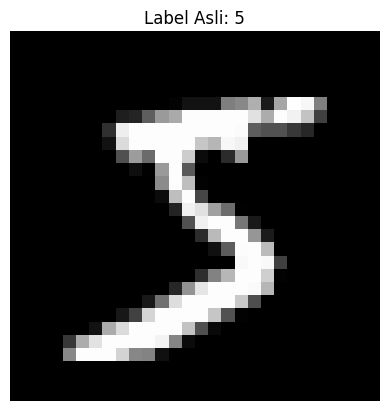

In [10]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label Asli: {y_train[0]}")
plt.axis('off')
plt.show()

In [11]:
X_train = X_train.reshape(60000, 784)
X_test  = X_test.reshape(10000, 784)


X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0


y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print("Data siap training!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Data siap training!
X_train shape: (60000, 784)
y_train shape: (60000, 10)


In [12]:
model = Sequential()


model.add(Dense(128, activation='relu', input_shape=(784,)))


model.add(Dense(64, activation='relu'))


model.add(Dense(10, activation='softmax'))


model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Training
print("Mulai Training...")
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=1)

Mulai Training...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8032 - loss: 0.6908 - val_accuracy: 0.9491 - val_loss: 0.1771
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9544 - loss: 0.1644 - val_accuracy: 0.9626 - val_loss: 0.1313
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9682 - loss: 0.1076 - val_accuracy: 0.9695 - val_loss: 0.1078
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0739 - val_accuracy: 0.9707 - val_loss: 0.0989
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9806 - loss: 0.0625 - val_accuracy: 0.9712 - val_loss: 0.0966
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9854 - loss: 0.0501 - val_accuracy: 0.9736 - val_loss: 0.0919
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9882 - loss: 0.0408 - val_accuracy: 0.9738 - val_loss: 0.0912
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9911 - loss: 0.0302 


Test Accuracy Final: 97.59%


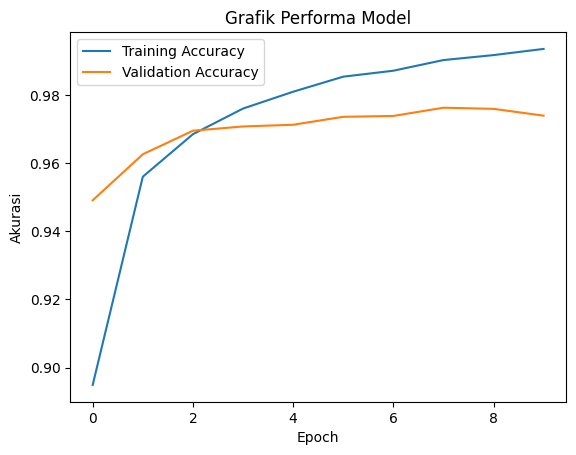

In [14]:
# Cek akurasi di data test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy Final: {test_acc*100:.2f}%")

# Gambar Grafik Akurasi
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Performa Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.show()